In [1]:
# Titanic Survival Prediction – Data Cleaning Project

In [4]:
import pandas as pd
df = pd.read_csv("Titanic-Dataset.csv")
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df["Age"].median()
df["Age"]=df["Age"].fillna(df["Age"].median())

In [12]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
df["Embarked"].mode()[0]

'S'

In [15]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [16]:
df.drop("Cabin", axis=1, inplace=True)

In [17]:
df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [18]:
# Encoding
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [19]:
df = pd.get_dummies(
    df,
    columns=["Embarked"],
    dtype=int
)


In [20]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare  Embarked_C  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500           0           0           1  
1          PC 17599  71.2833           1           0           0  
2  STON/O2. 3101282   7.9250           0           0           1  
3            113803  53.1000

In [23]:
# Using sklearn only for learning purpose
# import pandas as pd
# from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# # Encode Sex
# le = LabelEncoder()
# df["Sex"] = le.fit_transform(df["Sex"])

# # Encode Embarked
# ohe = OneHotEncoder(sparse_output=False)

# embarked_encoded = ohe.fit_transform(df[["Embarked"]])

# encoded_df = pd.DataFrame(
#     embarked_encoded,
#     columns=ohe.get_feature_names_out(["Embarked"]),
#     index=df.index
# )

# df = df.drop("Embarked", axis=1)
# df = pd.concat([df, encoded_df], axis=1)

# print(df.head())

In [30]:
import sys

print("Python used by Jupyter:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python used by Jupyter:
C:\Program Files\Python313\python.exe

Python version:
3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]


In [31]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

'C:\Program' is not recognized as an internal or external command,
operable program or batch file.


In [32]:
import sys
print(sys.executable)


C:\Program Files\Python313\python.exe


In [34]:
!"C:\Program Files\Python313\python.exe" -m pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Program Files\Python313\python.exe -m pip install --upgrade pip


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Matplotlib and Seaborn are working!")

Matplotlib and Seaborn are working!


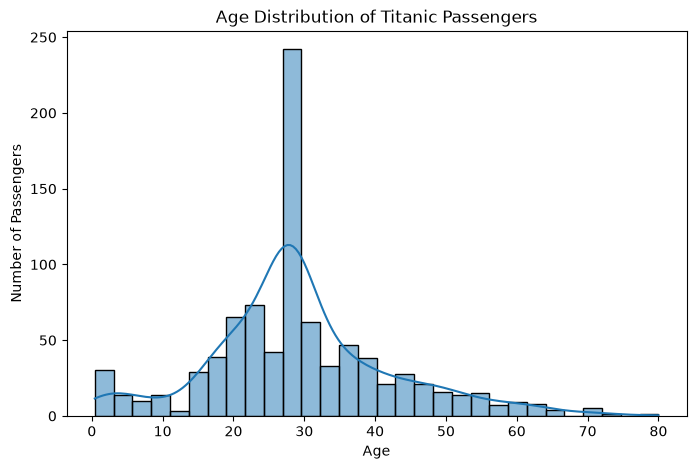

In [37]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [38]:
df.to_csv("Titanic-Cleaned.csv", index=False)